# HopeEXP — Task B: Detección de Emoción Desencadenante
**Modelo:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Clasificación multietiqueta (7 emociones)  
**Emociones:** sadness, joy, love, anger, fear, surprise, neutral

## 0. Setup e Imports

In [1]:
# Instalar dependencias si es necesario
!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached protobuf-7.34.0-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.12.1-py3-none-any.whl.metadata (4.3 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 16.6 MB/s  0:00:006.7 MB/s eta 0:00:0101
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 15.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 12.6 MB/s  0:00:00 20.7 MB/s eta 0:00:01
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-a

In [2]:
import sys
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Añadir el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath(".."))

from src.data_utils import (
    load_split,
    apply_cleaning,
    add_emotion_vectors,
    compute_class_weights,
    emotion_distribution,
    cooccurrence_matrix,
    format_predictions_for_submission,
    save_submission,
    EMOTION_LABELS,
)
from src.dataset import build_all_dataloaders
from src.model import build_model, build_tokenizer, load_model, count_parameters
from src.metrics import (
    compute_metrics,
    print_metrics,
    find_best_threshold,
    find_best_threshold_per_class,
    classification_report_str,
)
from src.trainer import train, evaluate_epoch, predict

print("Imports correctos")

/Users/adrian/Documents/Universidad/PLN/Practica-PLN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports correctos


In [3]:
# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cpu


## 1. Configuración de Hiperparámetros

In [4]:
# ── Rutas de datos ────────────────────────────────────────────
# Solo hay train y test
TRAIN_PATH = "./HopeEXP_Train.jsonl"
TEST_PATH  = "./HopeEXP_Test_unlabeled.jsonl"
DEV_SIZE   = 0.20   # fracción del train que se usará como dev

# ── Columnas del dataset ──────────────────────────────────────
# load_split() genera automáticamente estas columnas normalizadas:
#   title + selftext → text  |  trigger_emotions → emotions  |  row_id → id
TEXT_COL    = "text"
EMOTION_COL = "emotions"
ID_COL      = "id"
LANG_COL    = "lang"    # "EN" o "ES"

# ── Modelo ────────────────────────────────────────────────────
MODEL_NAME  = "microsoft/mdeberta-v3-base"
NUM_LABELS  = len(EMOTION_LABELS)   # 7
MAX_LENGTH  = 128                   # ajustar según el EDA de longitudes
DROPOUT     = 0.1

# ── Entrenamiento ─────────────────────────────────────────────
BATCH_SIZE  = 16
NUM_EPOCHS  = 10
LR          = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE    = 3           # épocas sin mejora para early stopping

# ── Evaluación ────────────────────────────────────────────────
THRESHOLD   = 0.5         # se optimizará en la sección de búsqueda
USE_POS_WEIGHT = True     # ponderar clases desbalanceadas

# ── Salidas ───────────────────────────────────────────────────
OUTPUT_DIR     = "./outputs"
BEST_MODEL_NAME = "best_model_task_b.pt"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuración lista")

Configuración lista


## 2. Carga y Preprocesamiento de Datos

In [5]:
from sklearn.model_selection import train_test_split as sk_split

# Cargar train completo y test (sin etiquetas)
full_train_df = load_split(TRAIN_PATH)
test_df       = load_split(TEST_PATH)

# Partir train en train/dev estratificando por primary_label
# para que ambos splits tengan la misma distribución de clases
train_df, dev_df = sk_split(
    full_train_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=full_train_df["primary_label"],
)
train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)

print(f"Train completo: {len(full_train_df)} muestras")
print(f"  → Train: {len(train_df)} | Dev: {len(dev_df)}  (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})")
print(f"  → Test (sin etiquetas): {len(test_df)} muestras")
print()
print("Distribución primary_label en train vs dev:")
dist_check = full_train_df.groupby("primary_label").size().rename("total")
dist_tr = train_df.groupby("primary_label").size().rename("train")
dist_dv = dev_df.groupby("primary_label").size().rename("dev")
import pandas as pd
print(pd.concat([dist_check, dist_tr, dist_dv], axis=1))

train_df.head(3)

Train completo: 4857 muestras
  → Train: 3885 | Dev: 972  (split 80/20)
  → Test (sin etiquetas): 2082 muestras

Distribución primary_label en train vs dev:
                  total  train  dev
primary_label                      
General Hope        937    749  188
Hopelessness        419    335   84
Not Hope           1400   1120  280
Realistic Hope      701    561  140
Sarcastic Hope      700    560  140
Unrealistic Hope    700    560  140


,row_id,lang,title,selftext,primary_label,span_annotations,trigger_emotions,text,emotions,id
0,5377,EN,My Partner Finally Remembered My Birthday—How ...,"After three years together, my significant oth...",Sarcastic Hope,[{'span': 'I have so much hope that things wil...,"[surprise, sadness, anger]",My Partner Finally Remembered My Birthday—How ...,"[surprise, sadness, anger]",5377
1,7161,EN,Reddittors make finding answers ridiculously t...,"Every reddit post that poses a question, the t...",Not Hope,[],[anger],Reddittors make finding answers ridiculously t...,[anger],7161
2,4124,ES,Alguien está o ha estado en una banda?,Me gustaría estar en una banda musical pero no...,Realistic Hope,[{'span': 'Me gustaría estar en una banda musi...,[Nuetral/unclear],Alguien está o ha estado en una banda?. Me gus...,[Nuetral/unclear],4124


In [6]:
# ── Limpieza de texto ─────────────────────────────────────────
# Ajusta los flags según los hallazgos del EDA
CLEAN_KWARGS = dict(
    remove_urls=True,
    remove_mentions=True,
    remove_hashtag_symbol=True,
    lowercase=False,   # DeBERTa es case-sensitive; mantener mayúsculas
)

train_df = apply_cleaning(train_df, text_col=TEXT_COL, **CLEAN_KWARGS)
dev_df   = apply_cleaning(dev_df,   text_col=TEXT_COL, **CLEAN_KWARGS)
# El test no tiene selftext etiquetado en algunos casos; se limpia igual
test_df = apply_cleaning(test_df, text_col=TEXT_COL, **CLEAN_KWARGS)

print("Ejemplo de texto limpio:")
print(train_df[TEXT_COL].iloc[0])

Ejemplo de texto limpio:
My Partner Finally Remembered My Birthday—How Refreshing. After three years together, my significant other actually showed up on time for once. Who knew it was possible? I mean, I only mentioned it casually forty-seven times in the past month. The flowers he grabbed from the gas station two minutes before arriving really set the romantic tone. And when he said 'happy birthday' while scrolling through his phone, I thought, 'wow, this is definitely the moment I'll cherish forever.' I'm sure next year will be even more special—maybe he'll remember without me having to create a calendar reminder for him. The bar is truly on the floor, but somehow he keeps finding new ways to limbo under it. I have so much hope that things will magically change without him actually putting in any effort whatsoever.


In [7]:
# ── Codificación de etiquetas a vectores binarios ─────────────
train_df = add_emotion_vectors(train_df, emotions_col=EMOTION_COL)
dev_df   = add_emotion_vectors(dev_df,   emotions_col=EMOTION_COL)

# Extraer listas para el Dataset
train_texts  = train_df[TEXT_COL].tolist()
train_labels = train_df["emotion_vector"].tolist()

dev_texts    = dev_df[TEXT_COL].tolist()
dev_labels   = dev_df["emotion_vector"].tolist()

# Test no tiene etiquetas — solo textos e ids
test_texts = test_df[TEXT_COL].tolist()
test_ids   = test_df[ID_COL].tolist()

print("Vector de ejemplo:", train_labels[0])
print("Emociones:         ", [EMOTION_LABELS[i] for i, v in enumerate(train_labels[0]) if v == 1])

Vector de ejemplo: [1, 0, 0, 1, 0, 1, 0]
Emociones:          ['sadness', 'anger', 'surprise']


## 3. Análisis de Desbalanceo de Clases

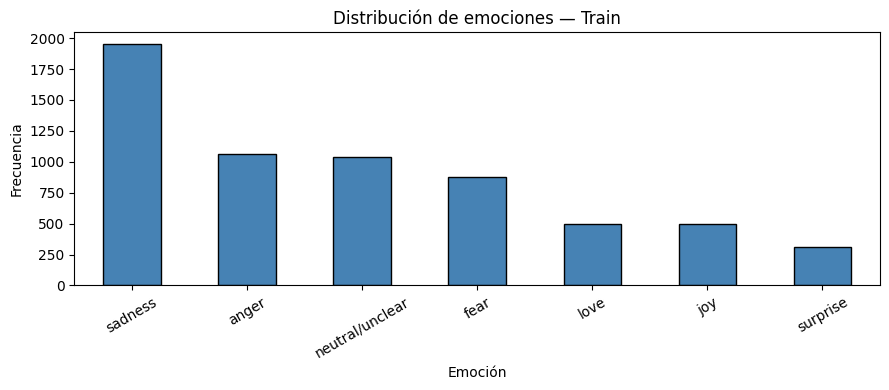

sadness            1949
anger              1061
neutral/unclear    1040
fear                875
love                498
joy                 494
surprise            311
dtype: int64


In [8]:
# Distribución de emociones en train
dist = emotion_distribution(train_df, emotions_col=EMOTION_COL)

fig, ax = plt.subplots(figsize=(9, 4))
dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribución de emociones — Train")
ax.set_xlabel("Emoción")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "emotion_distribution.png"), dpi=150)
plt.show()
print(dist)

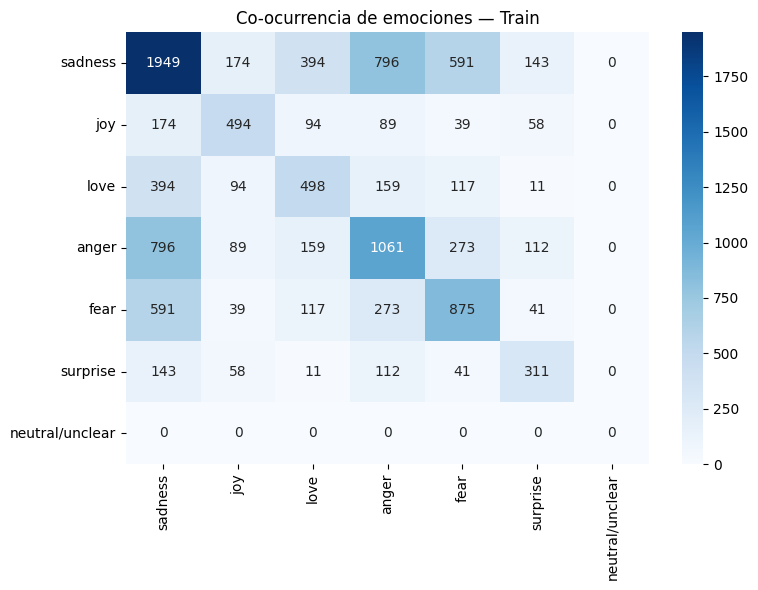

In [9]:
# Matriz de co-ocurrencia
cooc = cooccurrence_matrix(train_df, emotions_col=EMOTION_COL)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Co-ocurrencia de emociones — Train")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "emotion_cooccurrence.png"), dpi=150)
plt.show()

In [10]:
# ── Pesos positivos para BCEWithLogitsLoss ────────────────────
pos_weights_np = compute_class_weights(train_df, emotions_col=EMOTION_COL)
pos_weight = torch.tensor(pos_weights_np) if USE_POS_WEIGHT else None

print("Pesos positivos por clase:")
for label, w in zip(EMOTION_LABELS, pos_weights_np):
    print(f"  {label:12s}: {w:.2f}")

Pesos positivos por clase:
  sadness     : 0.99
  joy         : 6.86
  love        : 6.80
  anger       : 2.66
  fear        : 3.44
  surprise    : 11.49
  neutral/unclear: 2.74


## 4. Tokenizador y DataLoaders

In [11]:
tokenizer = build_tokenizer(MODEL_NAME)
print(f"Tokenizer cargado: {MODEL_NAME}")

# Verificar longitudes reales de los textos
sample_lengths = [
    len(tokenizer.encode(t, add_special_tokens=True))
    for t in train_texts[:500]
]
print(f"Longitud media tokens (muestra 500): {np.mean(sample_lengths):.1f}")
print(f"Percentil 95: {np.percentile(sample_lengths, 95):.0f}")
print(f"Máximo: {max(sample_lengths)}")
print(f"MAX_LENGTH configurado: {MAX_LENGTH}")

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 332.8
Percentil 95: 770
Máximo: 5954
MAX_LENGTH configurado: 128


In [12]:
loaders = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_labels,
    dev_texts=dev_texts,
    dev_labels=dev_labels,
    tokenizer=tokenizer,
    test_texts=test_texts,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"Batches — Train: {len(loaders['train'])} | Dev: {len(loaders['dev'])}", end="")
if "test" in loaders:
    print(f" | Test: {len(loaders['test'])}")
else:
    print()

# Verificar un batch
sample_batch = next(iter(loaders["train"]))
print("\nForma de un batch:")
for k, v in sample_batch.items():
    print(f"  {k}: {v.shape}")

Batches — Train: 243 | Dev: 61 | Test: 131

Forma de un batch:
  input_ids: torch.Size([16, 128])
  attention_mask: torch.Size([16, 128])
  token_type_ids: torch.Size([16, 128])
  labels: torch.Size([16, 7])


## 5. Construcción del Modelo

In [13]:
model = build_model(
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
)
model = model.float()

n_params = count_parameters(model)
print(f"Parámetros entrenables: {n_params:,}")
print(f"Cabeza clasificadora: {NUM_LABELS} etiquetas")

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 85010.97it/s]
DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 

N

Parámetros entrenables: 278,224,135
Cabeza clasificadora: 7 etiquetas


## 6. Entrenamiento

In [14]:
history = train(
    model=model,
    train_loader=loaders["train"],
    dev_loader=loaders["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight,
    save_dir=OUTPUT_DIR,
    model_name=BEST_MODEL_NAME,
    early_stopping_patience=PATIENCE,
    monitor_metric="f1_macro",
    verbose=True,
)

Iniciando entrenamiento: 10 épocas, lr=2e-05
- Total steps: 2430 | Warmup steps: 243
- Early stopping: patience=3, monitor='f1_macro'

Época 1/10  [652.3s]
- Train Loss: 1.2065  |  Dev Loss: 1.0159
- Dev f1_macro: 0.4246
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.4246)

Época 2/10  [656.4s]
- Train Loss: 0.8913  |  Dev Loss: 0.8104
- Dev f1_macro: 0.5377
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.5377)

Época 3/10  [653.6s]
- Train Loss: 0.7427  |  Dev Loss: 0.7561
- Dev f1_macro: 0.5603
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.5603)

Época 4/10  [656.2s]
- Train Loss: 0.6311  |  Dev Loss: 0.7345
- Dev f1_macro: 0.5675
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.5675)

Época 5/10  [613.9s]
- Train Loss: 0.5381  |  Dev Loss: 0.7828
- Dev f1_macro: 0.6155
Modelo guardado en ./outputs/best_model_task_b.

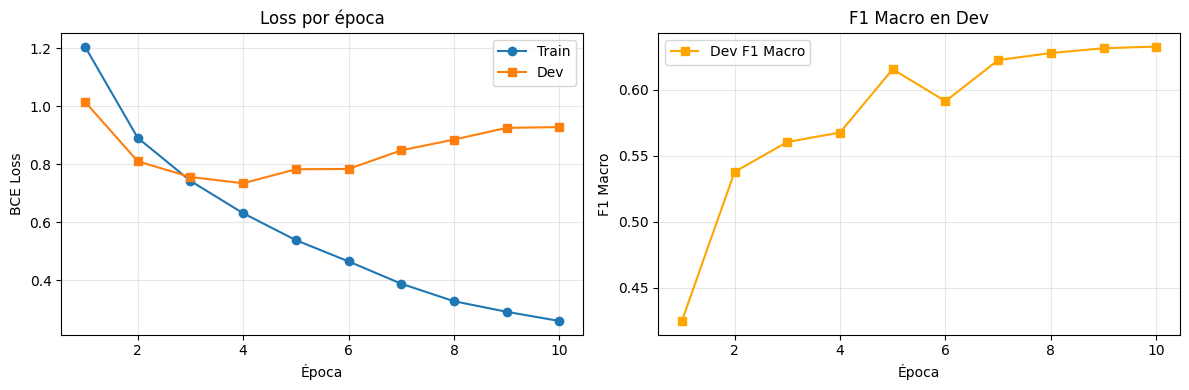

In [15]:
# ── Curvas de entrenamiento ───────────────────────────────────
epochs_run = range(1, len(history["train_loss"]) + 1)
dev_f1 = [m.get("f1_macro", 0) for m in history["dev_metrics"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs_run, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_run, history["dev_loss"],   label="Dev",   marker="s")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 Macro
axes[1].plot(epochs_run, dev_f1, label="Dev F1 Macro", marker="s", color="orange")
axes[1].set_title("F1 Macro en Dev")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 7. Evaluación del Mejor Modelo en Dev

In [18]:
# Cargar el mejor checkpoint guardado
best_model = load_model(
    path=os.path.join(OUTPUT_DIR, BEST_MODEL_NAME),
    model_name=MODEL_NAME,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
    device=DEVICE,
)

best_model = best_model.float()

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 82807.08it/s]
DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 

N

Modelo cargado desde ./outputs/best_model_task_b.pt


In [19]:
# Obtener probabilidades en dev
_, _, dev_probs, dev_true = evaluate_epoch(
    best_model, loaders["dev"], DEVICE, threshold=THRESHOLD
)

print(f"Formas — probs: {dev_probs.shape} | labels: {dev_true.shape}")

Formas — probs: (972, 7) | labels: (972, 7)


In [20]:
# ── Métricas con umbral por defecto (0.5) ─────────────────────
print("=== Evaluación con threshold=0.5 ===")
metrics_05 = compute_metrics(dev_true, dev_probs, threshold=0.5)
print_metrics(metrics_05)

print("\n" + classification_report_str(dev_true, dev_probs, threshold=0.5))

=== Evaluación con threshold=0.5 ===
  F1 Macro:    0.6327
  F1 Micro:    0.6569
  F1 Weighted: 0.6642
  Precision:   0.5726
  Recall:      0.7163
  Hamming Loss:0.1753
  Threshold:   0.50
--------------------------------------------------
  F1 por emoción:
    sadness     : 0.7387
    joy         : 0.4720
    love        : 0.5909
    anger       : 0.6656
    fear        : 0.5638
    surprise    : 0.6477
    neutral/unclear: 0.7500

                 precision    recall  f1-score   support

        sadness       0.70      0.78      0.74       489
            joy       0.38      0.63      0.47       120
           love       0.52      0.69      0.59       113
          anger       0.60      0.74      0.67       274
           fear       0.48      0.69      0.56       244
       surprise       0.58      0.73      0.65        78
neutral/unclear       0.75      0.75      0.75       237

      micro avg       0.59      0.73      0.66      1555
      macro avg       0.57      0.72      0.63  

## 8. Optimización del Umbral de Decisión

In [21]:
# ── Búsqueda de umbral global ─────────────────────────────────
print("=== Búsqueda de umbral global (maximiza F1 Macro) ===")
best_threshold, best_f1 = find_best_threshold(
    dev_true, dev_probs,
    metric="f1_macro",
    verbose=True,
)

=== Búsqueda de umbral global (maximiza F1 Macro) ===
   Threshold |     f1_macro
------------------------------
        0.10 |       0.5581
        0.15 |       0.5755
        0.20 |       0.5890
        0.25 |       0.5964
        0.30 |       0.6098
        0.35 |       0.6149
        0.40 |       0.6234
        0.45 |       0.6302
        0.50 |       0.6327
        0.55 |       0.6370
        0.60 |       0.6380
        0.65 |       0.6381
        0.70 |       0.6304
        0.75 |       0.6352
        0.80 |       0.6276
        0.85 |       0.6142
        0.90 |       0.5992

✅ Mejor umbral: 0.65  (f1_macro = 0.6381)


In [22]:
# ── Búsqueda de umbral por clase ──────────────────────────────
print("=== Búsqueda de umbral óptimo por clase ===")
best_thresholds_per_class = find_best_threshold_per_class(
    dev_true, dev_probs,
    label_names=EMOTION_LABELS,
)

=== Búsqueda de umbral óptimo por clase ===
Emoción         |   Umbral |       F1
--------------------------------------
sadness         |     0.15 |   0.7533
joy             |     0.90 |   0.4775
love            |     0.65 |   0.6250
anger           |     0.55 |   0.6723
fear            |     0.75 |   0.5835
surprise        |     0.90 |   0.7172
neutral/unclear |     0.35 |   0.7633


In [23]:
# ── Métricas con mejor umbral global ─────────────────────────
print(f"=== Evaluación con threshold={best_threshold:.2f} ===")
metrics_best = compute_metrics(dev_true, dev_probs, threshold=best_threshold)
print_metrics(metrics_best)

# Guardar el umbral óptimo para inferencia
OPTIMAL_THRESHOLD = best_threshold
print(f"\n✅ Umbral óptimo guardado: {OPTIMAL_THRESHOLD:.2f}")

=== Evaluación con threshold=0.65 ===
  F1 Macro:    0.6381
  F1 Micro:    0.6587
  F1 Weighted: 0.6638
  Precision:   0.6216
  Recall:      0.6609
  Hamming Loss:0.1589
  Threshold:   0.65
--------------------------------------------------
  F1 por emoción:
    sadness     : 0.7194
    joy         : 0.4583
    love        : 0.6250
    anger       : 0.6715
    fear        : 0.5803
    surprise    : 0.6627
    neutral/unclear: 0.7494

✅ Umbral óptimo guardado: 0.65


In [24]:
# ── Comparativa umbral por clase vs global ────────────────────
# Aplicar umbrales por clase manualmente
dev_pred_per_class = (dev_probs >= best_thresholds_per_class).astype(int)

from sklearn.metrics import f1_score
f1_per_class_thresh = f1_score(dev_true, dev_pred_per_class, average="macro", zero_division=0)
print(f"F1 Macro con umbrales por clase: {f1_per_class_thresh:.4f}")
print(f"F1 Macro con umbral global ({OPTIMAL_THRESHOLD:.2f}): {best_f1:.4f}")
print("→ Usar la estrategia con mayor F1 Macro")

F1 Macro con umbrales por clase: 0.6560
F1 Macro con umbral global (0.65): 0.6381
→ Usar la estrategia con mayor F1 Macro


## 9. Análisis de Errores

In [25]:
from src.metrics import binarize

dev_pred = binarize(dev_probs, OPTIMAL_THRESHOLD)

# Ejemplos mal clasificados
errors = []
for i in range(len(dev_texts)):
    true_emotions = [EMOTION_LABELS[j] for j, v in enumerate(dev_true[i]) if v == 1]
    pred_emotions = [EMOTION_LABELS[j] for j, v in enumerate(dev_pred[i]) if v == 1]
    if true_emotions != pred_emotions:
        errors.append({
            "text":  dev_texts[i],
            "true":  true_emotions,
            "pred":  pred_emotions,
        })

error_rate = len(errors) / len(dev_texts) * 100
print(f"Muestras con al menos 1 error: {len(errors)} ({error_rate:.1f}%)")
print()

# Mostrar primeros 5 errores
for e in errors[:5]:
    print(f"Texto: {e['text'][:100]}...")
    print(f"  Real: {e['true']}")
    print(f"  Pred: {e['pred']}")
    print()

Muestras con al menos 1 error: 611 (62.9%)

Texto: Housing Dream Update: Found Perfect Home and Finally Fixed Everything. I'm so excited to share that ...
  Real: ['sadness', 'joy', 'love']
  Pred: ['sadness', 'love', 'anger']

Texto: Está mal pensar que es de mal gusto exigir regalos de marca?. Con la navidad cerca solemos preguntar...
  Real: ['neutral/unclear']
  Pred: []

Texto: ¿Cómo puedo conseguir que mi jefe me ame tanto que me ascienda sin hacer nada?. Llevo tres meses en ...
  Real: ['sadness', 'love']
  Pred: ['sadness', 'love', 'anger']

Texto: Claro, seguro que esta vez será diferente. Ahí estoy yo, otra vez esperando que mi pareja finalmente...
  Real: ['fear']
  Pred: ['sadness', 'anger', 'fear']

Texto: No sé qué estudiar. Todo lo que me gusta da dinero. Estoy estudiando hace 4 año estudiando una carre...
  Real: ['sadness']
  Pred: ['sadness', 'anger']



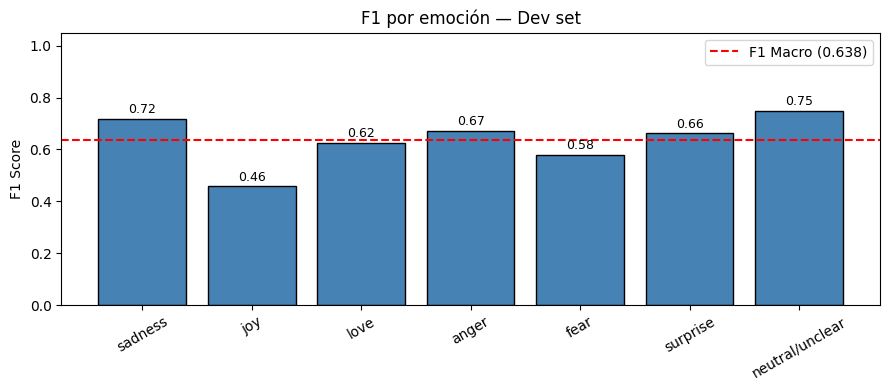

In [26]:
# F1 por clase — visualización
f1_per_class = [metrics_best.get(f"f1_{l}", 0) for l in EMOTION_LABELS]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(EMOTION_LABELS, f1_per_class, color="steelblue", edgecolor="black")
ax.axhline(metrics_best["f1_macro"], color="red", linestyle="--", label=f"F1 Macro ({metrics_best['f1_macro']:.3f})")
ax.set_title("F1 por emoción — Dev set")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "f1_per_class.png"), dpi=150)
plt.show()

## 10. Experimentos con Hiperparámetros (Opcional)

Ejecuta esta sección si quieres comparar diferentes configuraciones de LR o MAX_LENGTH.

In [ ]:
# EXPERIMENTOS DE LR — descomentar para ejecutar

# LEARNING_RATES = [1e-5, 2e-5, 3e-5]
# results_lr = {}

# for lr in LEARNING_RATES:
#     print(f"\n{'='*50}")
#     print(f"Experimento LR = {lr}")
#     print(f"{'='*50}")
#     set_seed(SEED)
#     exp_model = build_model(MODEL_NAME, NUM_LABELS, DROPOUT)
#     exp_history = train(
#         model=exp_model,
#         train_loader=loaders["train"],
#         dev_loader=loaders["dev"],
#         device=DEVICE,
#         num_epochs=5,
#         learning_rate=lr,
#         warmup_ratio=WARMUP_RATIO,
#         pos_weight=pos_weight,
#         save_dir=OUTPUT_DIR,
#         model_name=f"model_lr{lr}.pt",
#         early_stopping_patience=2,
#         verbose=True,
#     )
#     best_dev_f1 = max(m.get("f1_macro", 0) for m in exp_history["dev_metrics"])
#     results_lr[lr] = best_dev_f1
#     print(f"Mejor F1 Macro: {best_dev_f1:.4f}")

# print("\nResumen LR:")
# for lr, f1 in sorted(results_lr.items(), key=lambda x: x[1], reverse=True):
#     print(f"  LR={lr}: F1={f1:.4f}")

print("(Experimentos de LR comentados — descomentar para ejecutar)")

## 11. Generación de Predicciones para Test (Submission)

In [27]:
print("Generando predicciones para test...")
test_probs = predict(best_model, loaders["test"], DEVICE)
print(f"Probabilidades test: {test_probs.shape}")

Generando predicciones para test...
Probabilidades test: (2082, 7)


In [28]:
# Usar el umbral óptimo encontrado en dev
submission_df = format_predictions_for_submission(
        ids=test_ids,
        predictions=test_probs,
        label_set=EMOTION_LABELS,
        threshold=OPTIMAL_THRESHOLD,
    )

print(f"Submission — primeras filas:")
print(submission_df.head())
print(f"\nDistribución de predicciones en test:")
all_preds = [e for emotions in submission_df["emotions"] for e in emotions]
from collections import Counter
print(Counter(all_preds))

Submission — primeras filas:
     id           emotions
0    17   [sadness, anger]
1  3512  [neutral/unclear]
2  4863  [neutral/unclear]
3  6917        [joy, fear]
4  8586    [joy, surprise]

Distribución de predicciones en test:
Counter({'sadness': 1001, 'fear': 599, 'anger': 598, 'neutral/unclear': 473, 'joy': 363, 'love': 304, 'surprise': 191})


In [29]:
submission_path = os.path.join(OUTPUT_DIR, "submission_task_b.json")
save_submission(submission_df, submission_path)
print(f"✅ Submission lista para subir a CodaBench: {submission_path}")

Submission guardada en ./outputs/submission_task_b.json
✅ Submission lista para subir a CodaBench: ./outputs/submission_task_b.json


## 12. Guardado del Experimento

In [30]:
experiment_config = {
    "model_name":        MODEL_NAME,
    "max_length":        MAX_LENGTH,
    "batch_size":        BATCH_SIZE,
    "learning_rate":     LR,
    "warmup_ratio":      WARMUP_RATIO,
    "weight_decay":      WEIGHT_DECAY,
    "dropout":           DROPOUT,
    "use_pos_weight":    USE_POS_WEIGHT,
    "seed":              SEED,
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "best_dev_f1_macro": float(best_f1),
    "dev_metrics":       {k: float(v) for k, v in metrics_best.items()},
}

config_path = os.path.join(OUTPUT_DIR, "experiment_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("✅ Configuración del experimento guardada:")
print(json.dumps(experiment_config, indent=2))

✅ Configuración del experimento guardada:
{
  "model_name": "microsoft/mdeberta-v3-base",
  "max_length": 128,
  "batch_size": 16,
  "learning_rate": 2e-05,
  "warmup_ratio": 0.1,
  "weight_decay": 0.01,
  "dropout": 0.1,
  "use_pos_weight": true,
  "seed": 42,
  "optimal_threshold": 0.6500000000000001,
  "best_dev_f1_macro": 0.6380805581122299,
  "dev_metrics": {
    "f1_macro": 0.6380805581122299,
    "f1_micro": 0.6586675086832965,
    "f1_weighted": 0.6638495440649194,
    "precision_macro": 0.6216107535307861,
    "recall_macro": 0.6609289359345393,
    "hamming_loss": 0.1588771310993533,
    "threshold": 0.6500000000000001,
    "f1_sadness": 0.7194092827004219,
    "f1_joy": 0.4583333333333333,
    "f1_love": 0.625,
    "f1_anger": 0.6714542190305206,
    "f1_fear": 0.5802707930367504,
    "f1_surprise": 0.6626506024096386,
    "f1_neutral/unclear": 0.7494456762749445
  }
}
